# Analysis of NBA ESPN Fantasy League

## Questions looking to be answered

What players are the best value for their earnings?

What players create the largest fantasy points per game? (i.e. what fantasy team is the highest performing squad)

In 2020 ESPN introduced a new Fantasy Points scoring system. According to ESPN, this new system better reflected the Modern NBA. The scoring system is as follows:

- Point = 1

- 3PM = 1 (3 Point Make)

- FGA = -1 (Field Goal Attemp)

- FGM = 2 (Field Goal Make)

- FTA = -1 (Free Throw Attempt)

- FTM = 1 (Free Throw Make)

- REB = 1 (Rebound)

- AST = 2 (Assist)

- STL = 4 (Steal)

- BLK = 4 (Block)

- TOV = -2 (Turnover)

## Data

The data is a Kaggle Dataset which can be found here: https://www.kaggle.com/datasets/ratin21/nba-player-stats-and-salaries-2000-2025

Initial Data had issues with incorrect Player Names. I manually made the changes and remade the datatset done below. Initial data found on the github page: https://github.com/edwinjeon/NBA-Salary-Prediction

In [169]:
import pandas as pd
file_name = 'my_data.csv'

data = pd.read_csv(file_name)
data.head()

,Player,Salary,Year,Pos,Age,Team,G,GS,MP,FG,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,Shaquille O'Neal,17142000,2000,C,27.0,LAL,79.0,79.0,40.0,12.1,...,0.524,4.3,9.4,13.6,3.8,0.5,3.0,2.8,3.2,29.7
1,Kevin Garnett,16806000,2000,PF,23.0,MIN,81.0,81.0,40.0,9.4,...,0.765,2.8,9.0,11.8,5.0,1.5,1.6,3.3,2.5,22.9
2,Alonzo Mourning,15004000,2000,C,29.0,MIA,79.0,78.0,34.8,8.3,...,0.711,2.7,6.8,9.5,1.6,0.5,3.7,2.7,3.9,21.7
3,Juwan Howard,15000000,2000,PF,26.0,WAS,82.0,82.0,35.5,6.2,...,0.735,1.6,4.1,5.7,3.0,0.8,0.3,2.7,3.6,14.9
4,Scottie Pippen,14795000,2000,SF,34.0,POR,82.0,82.0,33.5,4.7,...,0.717,1.4,4.9,6.3,5.0,1.4,0.5,2.5,2.5,12.5


In [6]:
data_current = data

Some players are listed with multiple positions (e.g., SG-PG, PF-C). For simplicity, the first listed position is taken as the player's primary position. Multi-position players account for only a small proportion of the dataset (approximately 2%), so this simplification is unlikely to materially affect positional summary statistics.

In [7]:
data_current['Pos'].value_counts()

Pos
SG       2144
PG       1898
SF       1830
PF       1795
C        1400
SF-SG      28
PG-SG      28
SG-PG      23
SG-SF      21
PF-SF      19
C-PF       18
PF-C       17
SF-PF      17
SG-PF       4
PG-SF       1
SF-C        1
Name: count, dtype: int64

In [8]:
data_current['Pos'] = data_current['Pos'].str.split('-').str[0]
data_current['Pos'].value_counts()

Pos
SG    2192
PG    1927
SF    1876
PF    1831
C     1418
Name: count, dtype: int64

Next we will map the data's headers to the Fantasy Points structure for consistency.

In [9]:
print(data_current.columns)

Index(['Player', 'Salary', 'Year', 'Pos', 'Age', 'Team', 'G', 'GS', 'MP', 'FG',
       'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT',
       'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF',
       'PTS'],
      dtype='object')


In [10]:
new_columns = {'PTS': 'Points', '3P': '3PM', 'FGA': 'FGA', 'FG': 'FGM', 'FTA': 'FTA', 'FT': 'FTM', 'TRB': 'REB', 'AST': 'AST', 'STL': 'STL', 'BLK': 'BLK', 'TOV': 'TOV'}

data_current = data_current.rename(columns=new_columns)
print(data_current.columns)

Index(['Player', 'Salary', 'Year', 'Pos', 'Age', 'Team', 'G', 'GS', 'MP',
       'FGM', 'FGA', 'FG%', '3PM', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%',
       'FTM', 'FTA', 'FT%', 'ORB', 'DRB', 'REB', 'AST', 'STL', 'BLK', 'TOV',
       'PF', 'Points'],
      dtype='object')


Now we calculate all of the players fantasy points and add it as a column in the dataframe.

In [ ]:
# FPPG = Fantasy Points Per Game
data_current['FPPG'] = ( data_current['Points'] 
                                  + data_current['3PM'] - data_current['FGA'] + (data_current['FGM'] * 2) - data_current['FTA'] 
                                  + data_current['FTM'] + data_current['REB'] + (data_current['AST'] * 2) + (data_current['STL'] * 4)
                                  + (data_current['BLK'] * 4) - (data_current['TOV'] * 2) 
)

# FPPGS = Fantasy Points Per Game Starter

# TFP = Total Fantasy Points
data_current['TFP'] = data_current['G'] * data_current['FPPG']

# FPPM = Fantasy Points Per Minute
data_current['FPPM'] = round(data_current['TFP'] / (data_current['MP'] * data_current['G']), 2)

# FPPD = Fantasy Points Per Dollar
data_current['FPPD'] = data_current['TFP'] / (data_current['Salary'] * data_current['G']) / 82

DATA = data_current
DATA.head()

,Player,Salary,Year,Pos,Age,Team,G,GS,MP,FGM,...,AST,STL,BLK,TOV,PF,Points,FPPG,TFP,FPPM,FPPD
0,Shaquille O'Neal,17142000,2000,C,27.0,LAL,79.0,79.0,40.0,12.1,...,3.8,0.5,3.0,2.8,3.2,29.7,57.5,4542.5,1.44,4.090652e-08
1,Kevin Garnett,16806000,2000,PF,23.0,MIN,81.0,81.0,40.0,9.4,...,5.0,1.5,1.6,3.3,2.5,22.9,49.7,4025.7,1.24,3.606436e-08
2,Alonzo Mourning,15004000,2000,C,29.0,MIA,79.0,78.0,34.8,8.3,...,1.6,0.5,3.7,2.7,3.9,21.7,45.2,3570.8,1.30,3.673817e-08
3,Juwan Howard,15000000,2000,PF,26.0,WAS,82.0,82.0,35.5,6.2,...,3.0,0.8,0.3,2.7,3.6,14.9,23.6,1935.2,0.66,1.918699e-08
4,Scottie Pippen,14795000,2000,SF,34.0,POR,82.0,82.0,33.5,4.7,...,5.0,1.4,0.5,2.5,2.5,12.5,30.6,2509.2,0.91,2.522276e-08


### Players Fantasy Points Per Game vs Earnings for the 2025 Season

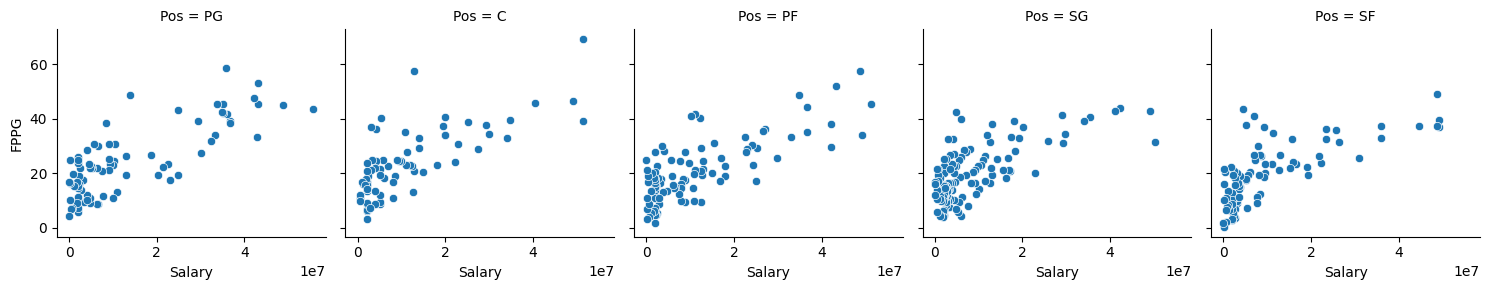

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(DATA[(DATA['Year'] == 2025) & (DATA['G'] >= 0)], col="Pos") # Wraps to 2 columns
g.map(sns.scatterplot, 'Salary', 'FPPG')
plt.show()

## Distributions of Fantasy Points by Position

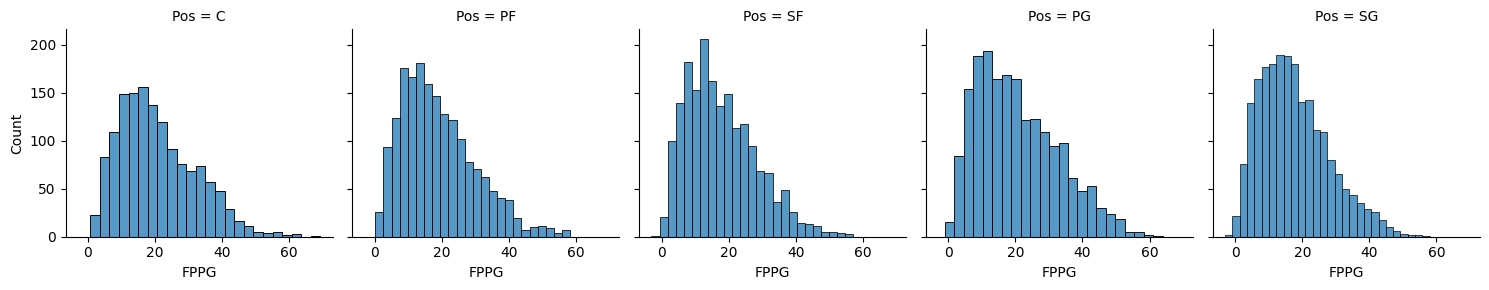

In [ ]:
POS = ['PG', 'SG', 'SF', 'PF', 'C']
g = sns.FacetGrid(DATA[DATA['Pos'].isin(['PG', 'SG', 'SF', 'PF', 'C'])], col="Pos") # Wraps to 2 columns
g.map(sns.histplot, "FPPG")
plt.show()

In [17]:
stats = DATA.groupby("Pos")["FPPG"].agg(["mean", "std"])

stats['dispersion'] = (stats['std'] ** 2) / stats['mean']
print(stats)

          mean        std  dispersion
Pos                                  
C    20.728773  11.378526    6.245948
PF   18.976952  11.040961    6.423730
PG   20.696783  12.121602    7.099327
SF   17.719829  10.480307    6.198527
SG   17.626232  10.308928    6.029309


## Best Fantasy Team In Each Season

We will assume a team size of 10 players.

### Function to Get Best Fantasy Team Each Season

This function simply takes the Highest totalling players in terms of fantasy points by position initially so that a "starting 5" can be produced. Then the next 5 are simply the next 5 highest scoring fantasy players.

In [168]:
def get_best_team(DATA, YEAR, TEAM_SIZE = 10):
    DATA_YEAR = DATA[DATA['Year'] == YEAR].sort_values(by='TFP', ascending=False).reset_index()

    TEAM = []

    POS = ['PG', 'SG', 'SF', 'PF', 'C']

    for pos in POS:
        DATA_SORTED = DATA_YEAR[DATA_YEAR['Pos'] == pos]
        INDEX = DATA_SORTED.index[0]
        DATA_POINT = DATA_SORTED.loc[INDEX]
        
        TEAM.append({'Name': DATA_POINT['Player'], 
                     'Games': DATA_POINT['G'],
                     'FPPG': round(DATA_POINT['FPPG'], 2), 
                     'TFP': round(DATA_POINT['TFP'], 2), 
                     'Salary': DATA_POINT['Salary'], 
                     'Position': pos, 
                     'Role': 'STARTER'})
        DATA_YEAR = DATA_YEAR.drop(INDEX, axis=0)

    for _, row in DATA_YEAR.head(TEAM_SIZE - 5).iterrows():
        TEAM.append({'Name': row['Player'], 
                     'Games': row['G'],
                     'FPPG': round(row['FPPG'], 2), 
                     'TFP': round(row['TFP'], 2), 
                     'Salary': row['Salary'], 
                     'Position': pos, 
                     'Role': 'BENCH'})
    return TEAM

# Get Best Teams

YEARS = DATA['Year'].unique()

BEST_TEAMS = {}

for year in YEARS:
    BEST_TEAMS[year] = get_best_team(DATA, year)

### Quick Statistics

In [167]:
def fantasy_team_stats(TEAM):

    TOTAL_F_POINTS = 0
    TOTAL_SALARY = 0
    TOTAL_F_POINTS_PER_GAME = 0
    AVERAGE_GAMES_PLAYED = 0

    for player in TEAM:
        TOTAL_F_POINTS += player['TFP']
        TOTAL_SALARY += player['Salary']
        TOTAL_F_POINTS_PER_GAME += player['FPPG']
        AVERAGE_GAMES_PLAYED += player['Games']

    return {
        "Total Fantasy Points": TOTAL_F_POINTS,
        "Total Fantasy Points Per Game": TOTAL_F_POINTS_PER_GAME,
        "Total Salary": TOTAL_SALARY,
        "Average Games Played": round(AVERAGE_GAMES_PLAYED/len(TEAM), 2)
    }

### 2025

In [30]:
BEST_TEAMS[2025]

[{'Name': 'Shai Gilgeous-Alexander',
  'Games': 76.0,
  'FPPG': 58.5,
  'TFP': 4446.0,
  'Salary': 35859950,
  'Position': 'PG',
  'Role': 'STARTER'},
 {'Name': 'Anthony Edwards',
  'Games': 79.0,
  'FPPG': 44.0,
  'TFP': 3476.0,
  'Salary': 42176400,
  'Position': 'SG',
  'Role': 'STARTER'},
 {'Name': 'LeBron James',
  'Games': 70.0,
  'FPPG': 49.2,
  'TFP': 3444.0,
  'Salary': 48728845,
  'Position': 'SF',
  'Role': 'STARTER'},
 {'Name': 'Giannis Antetokounmpo',
  'Games': 67.0,
  'FPPG': 57.5,
  'TFP': 3852.5,
  'Salary': 48787676,
  'Position': 'PF',
  'Role': 'STARTER'},
 {'Name': 'Nikola Jokic',
  'Games': 70.0,
  'FPPG': 69.4,
  'TFP': 4858.0,
  'Salary': 51415938,
  'Position': 'C',
  'Role': 'STARTER'},
 {'Name': 'James Harden',
  'Games': 79.0,
  'FPPG': 45.3,
  'TFP': 3578.7,
  'Salary': 33653846,
  'Position': 'C',
  'Role': 'BENCH'},
 {'Name': 'Jayson Tatum',
  'Games': 72.0,
  'FPPG': 48.6,
  'TFP': 3499.2,
  'Salary': 34848340,
  'Position': 'C',
  'Role': 'BENCH'},
 {'N

In [31]:
fantasy_team_stats(BEST_TEAMS[2025])

{'Total Fantasy Points': 37495.3,
 'Total Fantasy Points Per Game': 514.3000000000001,
 'Total Salary': 394620144,
 'Average Games Played': 73.2}

### By Season Comparison

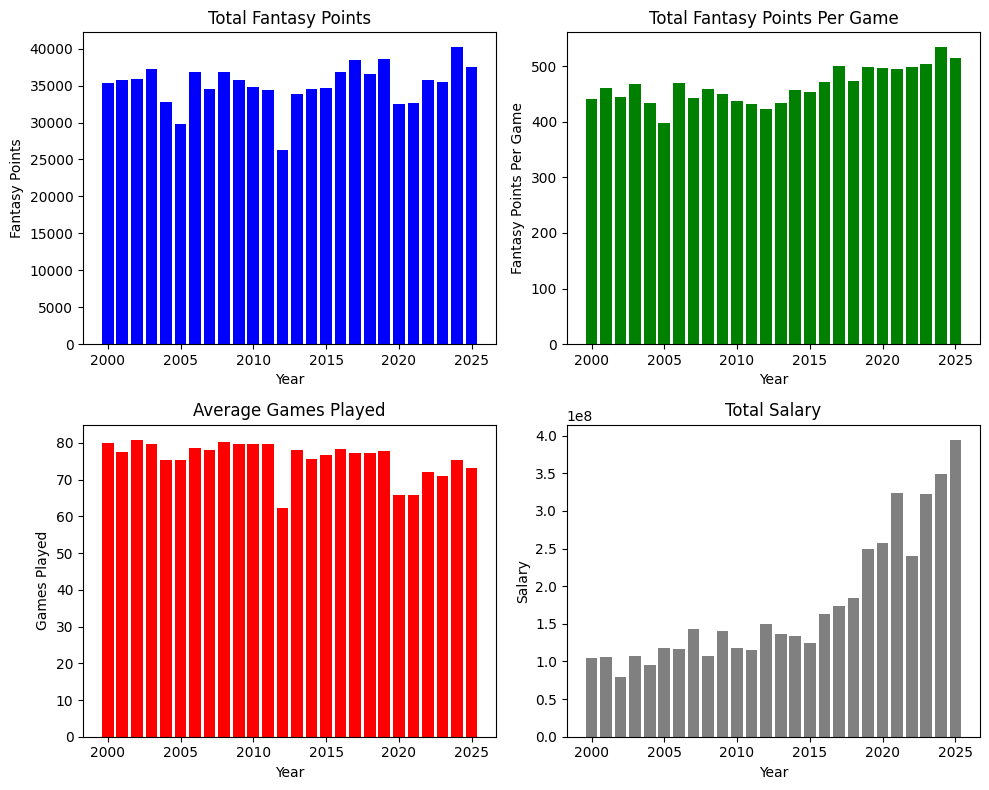

In [32]:
YEARS = DATA['Year'].unique()

FANTASY_TEAM_STATS = {}

for year in YEARS:
    FANTASY_TEAM_STATS[year] = fantasy_team_stats(BEST_TEAMS[year])

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].bar(YEARS, [FANTASY_TEAM_STATS[year]['Total Fantasy Points'] for year in YEARS], color="blue")
axs[0,0].set_title("Total Fantasy Points")
axs[0,0].set_xlabel('Year')
axs[0,0].set_ylabel('Fantasy Points')

axs[0,1].bar(YEARS, [FANTASY_TEAM_STATS[year]['Total Fantasy Points Per Game'] for year in YEARS], color="green")
axs[0,1].set_title("Total Fantasy Points Per Game")
axs[0,1].set_xlabel('Year')
axs[0,1].set_ylabel('Fantasy Points Per Game')

axs[1,0].bar(YEARS, [FANTASY_TEAM_STATS[year]['Average Games Played'] for year in YEARS], color="red")
axs[1,0].set_title("Average Games Played")
axs[1,0].set_xlabel('Year')
axs[1,0].set_ylabel('Games Played')

axs[1,1].bar(YEARS, [FANTASY_TEAM_STATS[year]['Total Salary'] for year in YEARS], color="grey")
axs[1,1].set_title("Total Salary")
axs[1,1].set_xlabel('Year')
axs[1,1].set_ylabel('Salary')

plt.tight_layout()

plt.show()

## Exploring Whether Teams of Same Positions are Better Against Other Teams With Full of Same Positions

In [33]:
def get_best_team_position(DATA, YEAR, POSITION, TEAM_SIZE = 10):
    DATA_YEAR = DATA[(DATA['Year'] == YEAR) & (DATA['Pos'] == POSITION)].sort_values(by='TFP', ascending=False).reset_index()

    TEAM = []

    for i in range(5):
        DATA_SORTED = DATA_YEAR[DATA_YEAR['Pos'] == POSITION]
        INDEX = DATA_SORTED.index[0]
        DATA_POINT = DATA_SORTED.loc[INDEX]
        
        TEAM.append({'Name': DATA_POINT['Player'], 
                     'Games': DATA_POINT['G'],
                     'FPPG': round(DATA_POINT['FPPG'], 2), 
                     'TFP': round(DATA_POINT['TFP'], 2), 
                     'Salary': DATA_POINT['Salary'], 
                     'Position': POSITION, 
                     'Role': 'STARTER'})
        DATA_YEAR = DATA_YEAR.drop(INDEX, axis=0)

    for idx, row in DATA_YEAR.head(TEAM_SIZE - 5).iterrows():
        TEAM.append({'Name': row['Player'], 
                     'Games': row['G'],
                     'FPPG': round(row['FPPG'], 2), 
                     'TFP': round(row['TFP'], 2), 
                     'Salary': row['Salary'], 
                     'Position': POSITION, 
                     'Role': 'BENCH'})
    return TEAM

YEARS = DATA['Year'].unique()

POS = ['PG', 'SG', 'SF', 'PF', 'C']

BEST_TEAMS_BY_YEAR_POSITIONS = {}

for year in YEARS:
    BEST_TEAMS_BY_YEAR_POSITIONS[year] = {}
    for pos in POS:
        BEST_TEAMS_BY_YEAR_POSITIONS[year][pos] = get_best_team_position(DATA, year, pos)

In [34]:
def run_comparison_positions(TEAMS):
    POS = ['PG', 'SG', 'SF', 'PF', 'C']

    YEARS_BEST = {pos: [] for pos in POS}

    for year in TEAMS.keys():
        BEST_POSITION = ''
        BEST_POSITION_VALUE = 0

        for pos in POS:
            STATS = fantasy_team_stats(TEAMS[year][pos])

            # print(BEST_POSITION, BEST_POSITION_VALUE)

            if STATS['Total Fantasy Points'] > BEST_POSITION_VALUE:
                BEST_POSITION = pos
                BEST_POSITION_VALUE = STATS['Total Fantasy Points']
        
        YEARS_BEST[BEST_POSITION].append(year)
    
    return YEARS_BEST


In [35]:
ANAYLSIS_OUT = run_comparison_positions(BEST_TEAMS_BY_YEAR_POSITIONS)

In [36]:
for pos in ANAYLSIS_OUT.keys():
    for year in ANAYLSIS_OUT[pos]:
        STATS_1 = fantasy_team_stats(BEST_TEAMS[year])
        STATS_2 = fantasy_team_stats(BEST_TEAMS_BY_YEAR_POSITIONS[year][pos])

        print(f"The best position only team in {year} was {pos} with a difference to the Best Team in the year by {round(STATS_1['Total Fantasy Points'] - STATS_2['Total Fantasy Points'], 2)}")

The best position only team in 2000 was PG with a difference to the Best Team in the year by 6459.1
The best position only team in 2007 was PG with a difference to the Best Team in the year by 6227.5
The best position only team in 2008 was PG with a difference to the Best Team in the year by 5961.7
The best position only team in 2009 was PG with a difference to the Best Team in the year by 6776.2
The best position only team in 2010 was PG with a difference to the Best Team in the year by 5967.7
The best position only team in 2011 was PG with a difference to the Best Team in the year by 5037.3
The best position only team in 2012 was PG with a difference to the Best Team in the year by 3873.5
The best position only team in 2013 was PG with a difference to the Best Team in the year by 4357.7
The best position only team in 2015 was PG with a difference to the Best Team in the year by 3486.4
The best position only team in 2016 was PG with a difference to the Best Team in the year by 3411.7


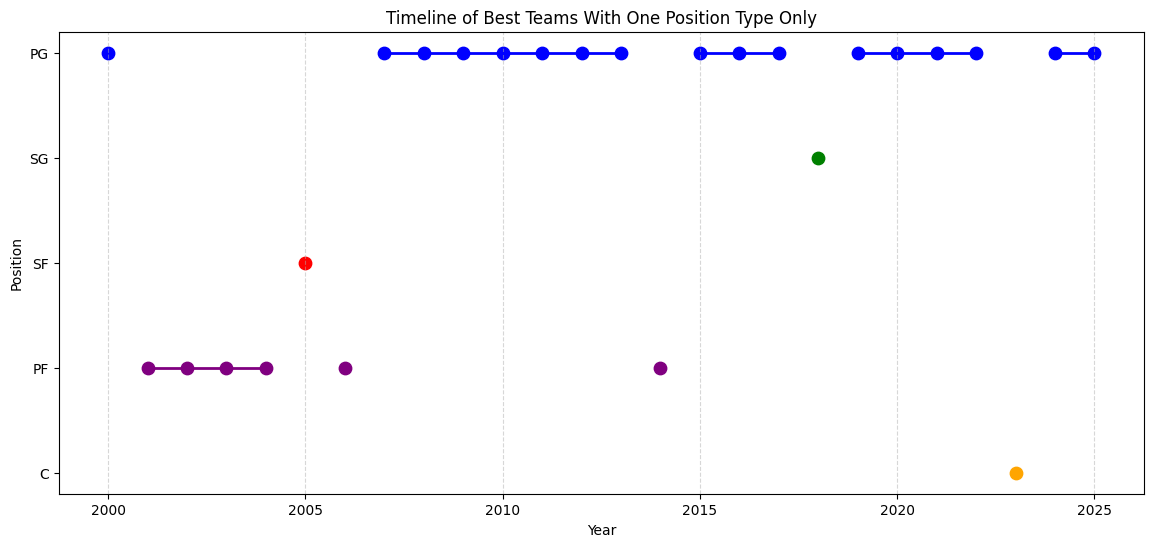

In [ ]:
positions = ['PG', 'SG', 'SF', 'PF', 'C'][::-1]
y_map = {pos: i for i, pos in enumerate(positions)}

fig, ax = plt.subplots(figsize=(14, 6))

colors = {
    'PG': 'blue',
    'SG': 'green',
    'SF': 'red',
    'PF': 'purple',
    'C': 'orange'
}

for pos, years in ANAYLSIS_OUT.items():
    years = sorted(years)
    y = y_map[pos]

    ax.scatter(years, [y]*len(years), s=80, color=colors[pos])

    for i in range(len(years) - 1):
        if years[i+1] == years[i] + 1:
            ax.plot([years[i], years[i+1]], [y, y],
                    color=colors[pos], linewidth=2)

ax.set_yticks(list(y_map.values()))
ax.set_yticklabels(list(y_map.keys()))
ax.set_xlabel("Year")
ax.set_ylabel("Position")
ax.set_title("Timeline of Best Teams With One Position Type Only")
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

## Optimising Teams Based on Salary Constraints and Position Requirements

### Salary Caps Across Seasons

![](salary.png)

This salary data was sourced from: https://basketball.realgm.com/nba/info/salary_cap

The subsequent csv file was created using ChatGPT to quickly write the file for me.

In [40]:
NBA_SALARY_DATA = pd.read_csv('nba_salary_data.csv')
NBA_SALARY_DATA.head()

,Season,Salary Cap,Luxury Tax,1st Apron,2nd Apron,BAE,Non-Taxpayer MLE,Taxpayer MLE,Team Room MLE
0,2025,140588000,170814000.0,178132000.0,188931000.0,4668000,12822000,5168000.0,7983000.0
1,2024,136021000,165294000.0,172346000.0,182794000.0,4516000,12405000,5000000.0,7723000.0
2,2023,123655000,150267000.0,156983000.0,NaN,4105000,10490000,6479000.0,5401000.0
3,2022,112414000,136606000.0,143002000.0,NaN,3732000,9536000,5890000.0,4910000.0
4,2021,109140000,132627000.0,138928000.0,NaN,3623000,9258000,5718000.0,4767000.0


In [163]:
import pulp

def optimise_team_salary(DF, SALARY_CAP, OBJECTIVE_VALUE = 'FPPG', INCLUDE_POSITION_CONSTRAINT = False, TEAM_SIZE = 10):
    DF = DF.reset_index()

    model = pulp.LpProblem("Optimise_Team_Based_on_Salary", pulp.LpMaximize)
    
    x = {
        i: pulp.LpVariable(f"x_{i}", cat="Binary")
        for i in DF.index
    }
    
    # Objective
    model += pulp.lpSum(DF.loc[i, OBJECTIVE_VALUE] * x[i] for i in DF.index)

    # Constraint: Team Size
    model += pulp.lpSum(x[i] for i in DF.index) == TEAM_SIZE

    # Constraint: Salary Cap
    model += pulp.lpSum(DF.loc[i, 'Salary'] * x[i] for i in DF.index) <= SALARY_CAP

    # Constraint: Positions
    if INCLUDE_POSITION_CONSTRAINT:
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "PG") >= 2
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "SG") >= 2
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "SF") >= 2
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "PF") >= 2
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "C") >= 2
    else:
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "PG") >= 1
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "SG") >= 1
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "SF") >= 1
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "PF") >= 1
        model += pulp.lpSum(x[i] for i in DF.index if DF.loc[i, "Pos"] == "C") >= 1
    
    model.solve()

    selected_indices = [i for i in DF.index if x[i].value() == 1]
    selected_df = DF.loc[selected_indices].copy()

    return selected_df


### Optimise for Every Year and Their Respective Salary Cap

In [164]:
YEARS = DATA['Year'].unique()

OPTIMISED_TEAMS = {year: optimise_team_salary(DATA[DATA['Year'] == year], NBA_SALARY_DATA[NBA_SALARY_DATA['Season'] == year]['Salary Cap']) for year in YEARS}

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /opt/anaconda3/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/nd/xc9s9y4x0sz6h6yt2lhl1lww0000gn/T/cb3dfad4241b4225904651da01b927cc-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/nd/xc9s9y4x0sz6h6yt2lhl1lww0000gn/T/cb3dfad4241b4225904651da01b927cc-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 12 COLUMNS
At line 829 RHS
At line 837 BOUNDS
At line 974 ENDATA
Problem MODEL has 7 rows, 136 columns and 408 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 363.88 - 0.00 seconds
Cgl0004I processed model has 7 rows, 136 columns (136 integer (136 of which binary)) and 408 elements
Cutoff increment increased from 1e-05 to 0.0999
Cbc0038I Initial state - 2 integers unsatisfied sum - 0.845396
Cbc0038I Pass   1: suminf.    0.74429 (2)

### Checking an Example for Season: 2025
The Salary Cap in 2025 was $140,588,000.

In [161]:
DATA_2025 = DATA[DATA['Year'] == 2025]

SALARY_CAP_2025 = 140588000

team = optimise_team_salary(DATA_2025, SALARY_CAP_2025, OBJECTIVE_VALUE='FPPG', INCLUDE_POSITION_CONSTRAINT=False)

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /opt/anaconda3/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/nd/xc9s9y4x0sz6h6yt2lhl1lww0000gn/T/c808d5d223a343bab1d51613e06b9556-pulp.mps -max -timeMode elapsed -branch -printingOptions all -solution /var/folders/nd/xc9s9y4x0sz6h6yt2lhl1lww0000gn/T/c808d5d223a343bab1d51613e06b9556-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 12 COLUMNS
At line 2785 RHS
At line 2793 BOUNDS
At line 3256 ENDATA
Problem MODEL has 7 rows, 462 columns and 1386 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 475.01 - 0.00 seconds
Cgl0004I processed model has 7 rows, 462 columns (462 integer (462 of which binary)) and 1386 elements
Cutoff increment increased from 1e-05 to 0.0999
Cbc0038I Initial state - 2 integers unsatisfied sum - 0.687454
Cbc0038I Pass   1: suminf.    0.4399

# Creating Predictive Model

## Preparing the Data

In [ ]:
df = DATA.copy()

# Time-Series Sort by Player
df = df.sort_values(['Player', 'Year'])

# Set the Target Variable
df['TARGET_FPPG_NEXT'] = df.groupby('Player')['FPPG'].shift(-1)

## Model Features

In [53]:
features = [
    'Age',
    'MP',
    'FPPG',
    'FPPM',
    'Points',
    'REB',
    'AST',
    'STL',
    'BLK',
    'TOV',
    'FG%',
    '3P%',
    'FT%',
]

df_model = df.dropna(subset=['TARGET_FPPG_NEXT']).copy()

## Train/Test Split

In [73]:
def train_test_split(TEST_YEAR):

    train_df = df_model[df_model['Year'] < TEST_YEAR]
    test_df  = df_model[df_model['Year'] == TEST_YEAR]

    X_train = train_df[features]
    y_train = train_df['TARGET_FPPG_NEXT']

    X_test = test_df[features]
    y_test = test_df['TARGET_FPPG_NEXT']

    return X_train, y_train, X_test, y_test

## Models

### Linear Regression Model

In [79]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

lin_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

### Elastic Net Model

In [119]:
from sklearn.linear_model import ElasticNet

enet = ElasticNet(alpha=0.01, l1_ratio=0.5)

### Random Forrest Model

In [120]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

### Light Gradient Boosting Model

In [121]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

### XGBoost

In [122]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

## Run Predictions

In [123]:
def run_predictions(TEST_YEAR = 2021):
    X_train, y_train, X_test, y_test = train_test_split(TEST_YEAR)

    lin_model.fit(X_train, y_train)
    y_pred_lin = lin_model.predict(X_test)

    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)

    lgbm_model.fit(X_train, y_train)
    y_pred_lgbm = lgbm_model.predict(X_test)

    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)

    enet.fit(X_train, y_train)
    y_pred_enet = enet.predict(X_test)

    return y_pred_lin, y_pred_rf, y_pred_lgbm, y_pred_xgb, y_pred_enet, y_test

## Model Evaluation

In [149]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{name}")
    print(f"MAE: {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R2: {r2:.3f}")
    print("-" * 30)

    return mae, rmse, r2, y_true, y_pred

In [ ]:
lin_model_results = {}
enet_model_results = {}
rf_model_results = {}
lgbm_model_results = {}
xgb_model_results = {}
ensemble_model_results = {}

YEARS = list(range(2001, 2025))

for year in YEARS:
    y_pred_lin, y_pred_rf, y_pred_lgbm, y_pred_xgb, y_pred_enet, y_test = run_predictions(year)

    mae, rmse, r2, y_true, y_pred = evaluate(y_test, y_pred_lin, "Linear Regression")
    lin_model_results[year] = {'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R2': round(r2, 2), 'y_true': y_true, 'y_pred': y_pred}

    mae, rmse, r2, y_true, y_pred = evaluate(y_test, y_pred_rf, "Random Forest")
    rf_model_results[year] = {'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R2': round(r2, 2), 'y_true': y_true, 'y_pred': y_pred}

    mae, rmse, r2, y_true, y_pred = evaluate(y_test, y_pred_lgbm, "LGBM")
    lgbm_model_results[year] = {'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R2': round(r2, 2), 'y_true': y_true, 'y_pred': y_pred}

    mae, rmse, r2, y_true, y_pred = evaluate(y_test, y_pred_xgb, "XGB")
    xgb_model_results[year] = {'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R2': round(r2, 2), 'y_true': y_true, 'y_pred': y_pred}

    mae, rmse, r2, y_true, y_pred = evaluate(y_test, y_pred_enet, "Elastic Net")
    enet_model_results[year] = {'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R2': round(r2, 2), 'y_true': y_true, 'y_pred': y_pred}

    stack_X = np.column_stack([
        y_pred_lin,
        y_pred_rf,
        y_pred_xgb,
        y_pred_lgbm,
        y_pred_enet
    ])

    meta_model = LinearRegression()
    meta_model.fit(stack_X, y_true)

    y_pred_ensemble = meta_model.predict(stack_X)

    mae, rmse, r2, y_true, y_pred = evaluate(y_test, y_pred_ensemble, "Ensemble")
    ensemble_model_results[year] = {'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R2': round(r2, 2), 'y_true': y_true, 'y_pred': y_pred}


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 432
[LightGBM] [Info] Number of data points in the train set: 134, number of used features: 13
[LightGBM] [Info] Start training from score 22.710448
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [159]:
def results_to_df(results_dict):
    rows = []
    
    for year, metrics in results_dict.items():
        rows.append({
            'Year': year,
            'MAE': metrics['MAE'],
            'RMSE': metrics['RMSE'],
            'R2': metrics['R2']
        })
    
    df = pd.DataFrame(rows)
    df = df.sort_values('Year')
    
    return df

lin_df = results_to_df(lin_model_results)
enet_df = results_to_df(enet_model_results)
rf_df = results_to_df(rf_model_results)
lgbm_df = results_to_df(lgbm_model_results)
xgb_df = results_to_df(xgb_model_results)
ensemble_df = results_to_df(ensemble_model_results)

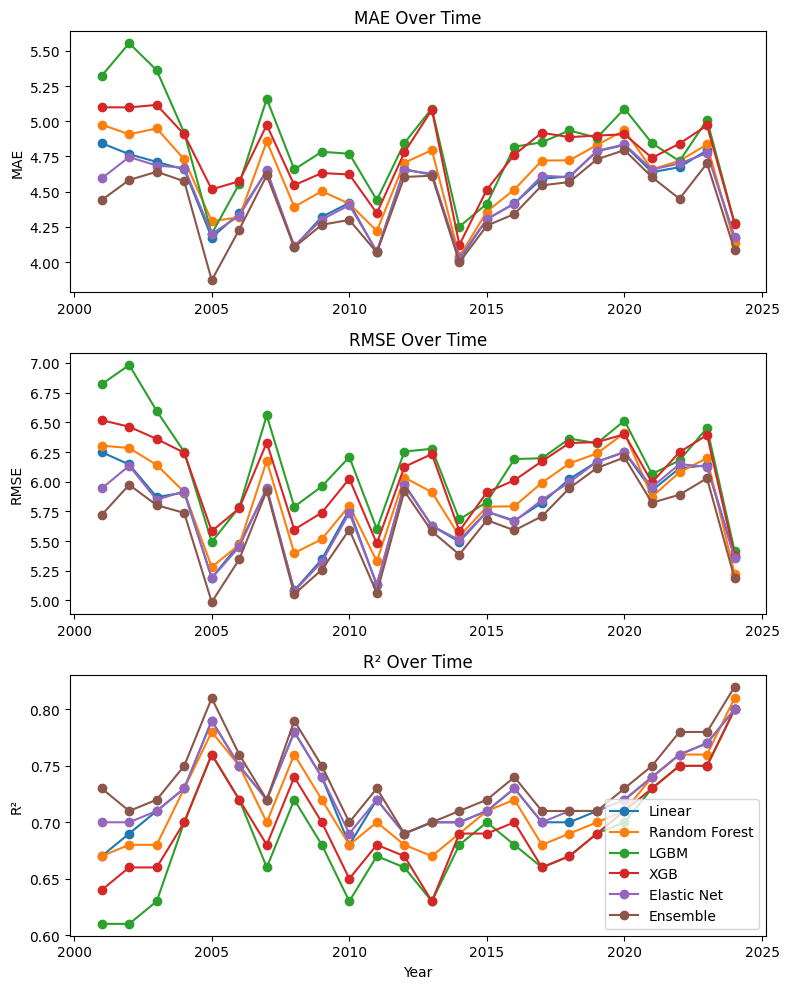

In [160]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10))

# MAE
axes[0].plot(lin_df['Year'], lin_df['MAE'], marker='o', label='Linear')
axes[0].plot(rf_df['Year'], rf_df['MAE'], marker='o', label='Random Forest')
axes[0].plot(rf_df['Year'], lgbm_df['MAE'], marker='o', label='LGBM')
axes[0].plot(rf_df['Year'], xgb_df['MAE'], marker='o', label='XGB')
axes[0].plot(rf_df['Year'], enet_df['MAE'], marker='o', label='Elastic Net')
axes[0].plot(rf_df['Year'], ensemble_df['MAE'], marker='o', label='Ensemble')
axes[0].set_title('MAE Over Time')
axes[0].set_ylabel('MAE')

# RMSE
axes[1].plot(lin_df['Year'], lin_df['RMSE'], marker='o', label='Linear')
axes[1].plot(rf_df['Year'], rf_df['RMSE'], marker='o', label='Random Forest')
axes[1].plot(rf_df['Year'], lgbm_df['RMSE'], marker='o', label='LGBM')
axes[1].plot(rf_df['Year'], xgb_df['RMSE'], marker='o', label='XGB')
axes[1].plot(rf_df['Year'], enet_df['RMSE'], marker='o', label='Elastic Net')
axes[1].plot(rf_df['Year'], ensemble_df['RMSE'], marker='o', label='Ensemble')
axes[1].set_title('RMSE Over Time')
axes[1].set_ylabel('RMSE')

# R2
axes[2].plot(lin_df['Year'], lin_df['R2'], marker='o', label='Linear')
axes[2].plot(rf_df['Year'], rf_df['R2'], marker='o', label='Random Forest')
axes[2].plot(rf_df['Year'], lgbm_df['R2'], marker='o', label='LGBM')
axes[2].plot(rf_df['Year'], xgb_df['R2'], marker='o', label='XGB')
axes[2].plot(rf_df['Year'], enet_df['R2'], marker='o', label='Elastic Net')
axes[2].plot(rf_df['Year'], ensemble_df['R2'], marker='o', label='Ensemble')
axes[2].set_title('R² Over Time')
axes[2].set_ylabel('R²')

plt.legend()

plt.xlabel('Year')
plt.tight_layout()
plt.show()

## Model Performance Comparison

The performance of several models was evaluated across multiple seasons using MAE, RMSE, and R² as metrics. These models included Linear Regression, Random Forest, XGBoost, LightGBM, Elastic Net, a manually weighted ensemble, and a stacked ensemble model.

Overall, the results show that the stacked ensemble model consistently achieved the best performance across all metrics. It produced the lowest MAE and RMSE in most seasons, indicating more accurate predictions, while also achieving the highest R² values, demonstrating superior explanatory power.

Among the individual models, Linear Regression and Elastic Net performed surprisingly well, particularly in terms of error metrics. This suggests that a large portion of the relationship between current season statistics and next season fantasy points per game can be captured through relatively stable linear trends.

The Random Forest model performed competitively, particularly in terms of R², indicating that nonlinear relationships and feature interactions do contribute to predictive performance. However, it was generally slightly outperformed by the linear models in MAE and RMSE.

The gradient boosting models (XGBoost and LightGBM) did not outperform the simpler models in this setting. This may indicate that the underlying signal in the data is not highly complex, or that further hyperparameter tuning would be required to fully leverage these models.

The manually weighted ensemble model improved performance over individual models, demonstrating that combining different model types can capture complementary aspects of the data. However, the stacked ensemble model further improved upon this by learning optimal combinations of model predictions, rather than relying on fixed weights.